In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 

# Data Cleaning

In [ ]:
# import data (still need to check the null value)
model_df = pd.read_csv("../Table/Model_df.csv")

model_df = model_df.dropna(subset="Poverty_Ra").drop("Unnamed: 0",axis=1)

model_df["GEOID_right"] = model_df["GEOID_right"].astype("str").str.replace(".0","")

print(f'Columns in the df contains:{model_df.columns.to_list()}')

Columns in the df contains:['Stop Code', 'stop_name', 'lattitude', 'longitude', '2026_complaint_counts', 'GEOID_right', '2026_may_avg_ridership', '2026_shelter_number', '2026_bench_number', '2026_trash_can_number', '2026_stop_surface', '2026_landing_type', '2026_sidewalk_connection', '2026_cross_walk', '2026_street_lighting', 'Poverty_Ra', 'Median_Hou', 'No_Vehic_1', 'Disability', 'Mean_Commu', 'Total popu', 'Black or A', 'Hispanic o', 'White alon', 'Age75Plus_']


In [3]:
#select variables for modeling
y_col = "2026_complaint_counts"

pred_cols = [
    "2026_may_avg_ridership",#direct association 

    "2026_shelter_number",
    "2026_bench_number",
    "2026_trash_can_number",#amenity features

    "Median_Hou",
    "No_Vehic_1",
    "Mean_Commu",
    "Total popu",
]

print(f'The target variable is {y_col}')
print(f'The predictors are {pred_cols}')

The target variable is 2026_complaint_counts
The predictors are ['2026_may_avg_ridership', '2026_shelter_number', '2026_bench_number', '2026_trash_can_number', 'Median_Hou', 'No_Vehic_1', 'Mean_Commu', 'Total popu']


# Data Engineering

In [4]:
# census tract effect data engineering
model_df["tract_idx"] = model_df["GEOID_right"].astype("category").cat.codes

tract_names = model_df["GEOID_right"].astype("category").cat.categories

In [5]:
# Standardizing Design Matrx
scaler = StandardScaler()

X = scaler.fit_transform(model_df[pred_cols]) # design matrix

y = model_df[y_col].values

tract_idx = model_df["tract_idx"].values

# Model Specification

In [6]:
# coordinates 
coords = {
    "obs":np.arange(X.shape[0]),
    "predictor":pred_cols,
    "tract":tract_names
}

In [7]:
with pm.Model(coords=coords) as ZINB:
    # data
    X_data = pm.Data("X",X,dims=("obs","predictor"))
    tract_data = pm.Data("tract_idx",tract_idx,dims="obs")

    # census tract effect 
    sigma_u = pm.HalfNormal("sigma_u",sigma=0.3)
    u = pm.Normal("u",mu=0,sigma=sigma_u,dims="tract")

    # - -count model- -
    # prior
    alpha = pm.Exponential("alpha",lam=1)
    beta0 = pm.Normal("beta0",mu=np.log(y.mean()+0.1),sigma=0.5)
    beta = pm.Normal("beta",mu=0,sigma=0.3,dims="predictor")

    eta_count = beta0 + pm.math.dot(X_data,beta)+u[tract_data]
    mu = pm.Deterministic("mu",pm.math.exp(eta_count),dims="obs")

    # zero model 
    gamma0 = pm.Normal("gamma0",mu=0,sigma=1)
    gamma = pm.Normal("gamma",mu=0,sigma=0.3,dims="predictor")

    eta_zero = gamma0 + pm.math.dot(X_data,gamma)
    psi = pm.Deterministic("psi",pm.math.sigmoid(eta_zero),dims="obs")

    # likelihood 
    y_obs = pm.ZeroInflatedNegativeBinomial(
        "y_obs",
        psi=psi,
        mu=mu,
        alpha=alpha,
        observed=y,
        dims="obs"
    )

    idata = pm.sample(
        chains=4,
        draws=2000,
        tune = 3000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_u, u, alpha, beta0, beta, gamma0, gamma]


/opt/anaconda3/envs/bus/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 36 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


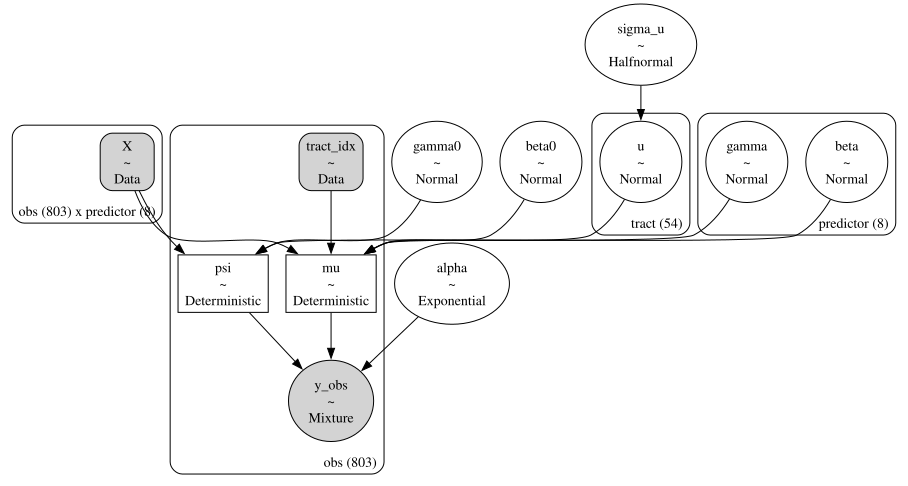

In [8]:
pm.model_to_graphviz(ZINB)

# MCMC Diagnoistics

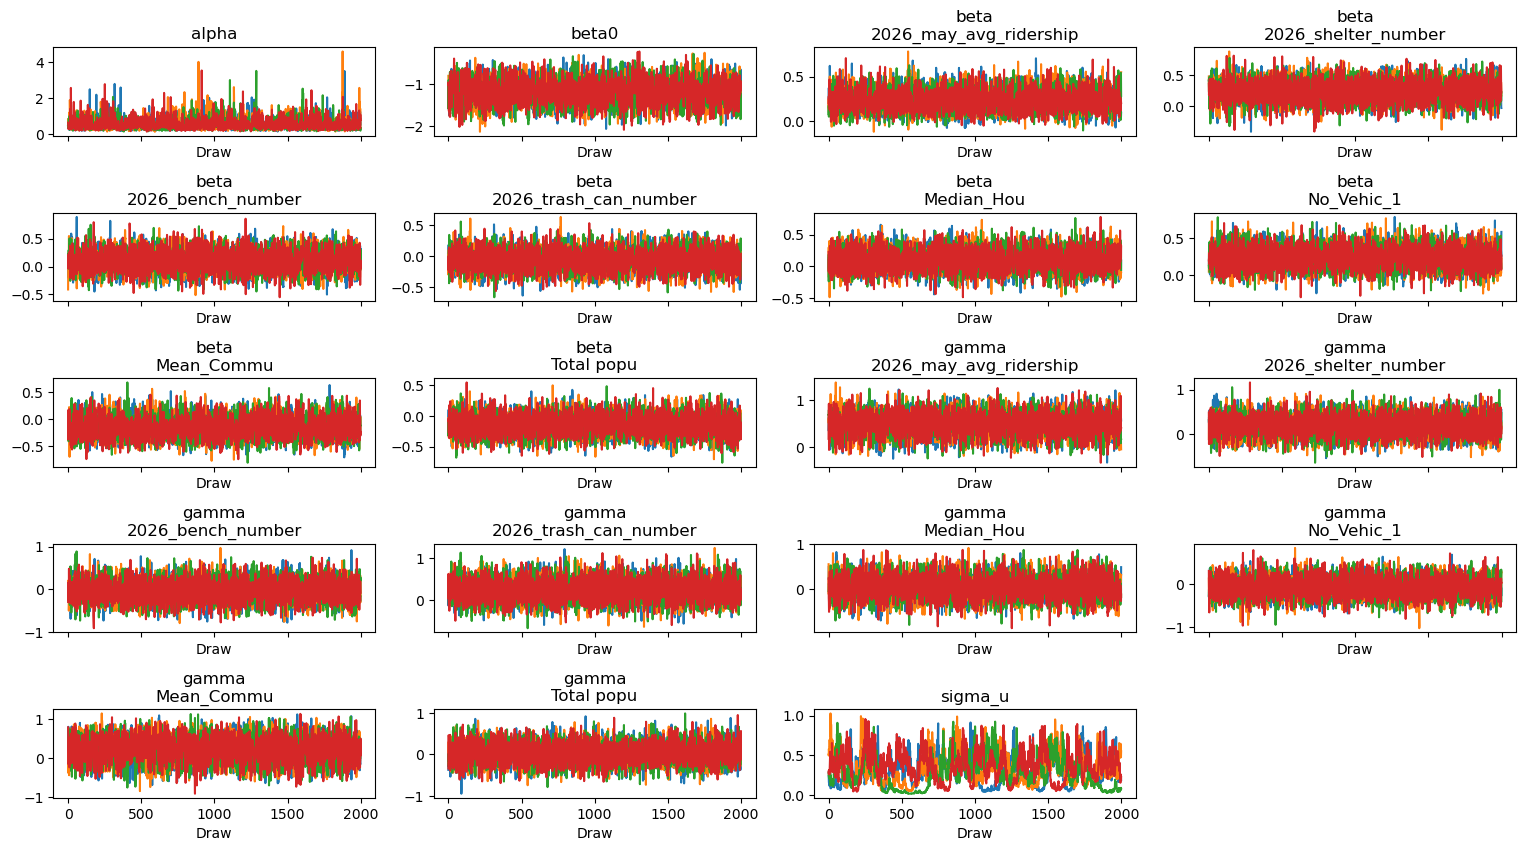

In [9]:
az.plot_trace(idata,var_names=["alpha","beta0","beta","gamma","sigma_u"])

plt.tight_layout()

In [10]:
az.summary(idata,var_names=["alpha","beta0","beta","gamma0","gamma","sigma_u"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.54,0.3,0.25,1.1,1450,3266,1.00,0.0069,0.015
beta0,-1.2,0.284,-1.7,-0.74,2935,3966,1.00,0.0052,0.0035
beta[2026_may_avg_ridership],0.234,0.12,0.056,0.44,3789,3965,1.00,0.002,0.0014
beta[2026_shelter_number],0.241,0.166,-0.026,0.5,4904,4902,1.00,0.0024,0.0017
beta[2026_bench_number],0.103,0.183,-0.19,0.4,4933,4645,1.00,0.0026,0.0019
beta[2026_trash_can_number],-0.063,0.162,-0.32,0.2,5085,5551,1.00,0.0023,0.0017
beta[Median_Hou],0.106,0.164,-0.15,0.37,4484,5084,1.00,0.0025,0.0017
beta[No_Vehic_1],0.24,0.144,0.013,0.47,5708,5933,1.00,0.0019,0.0014
beta[Mean_Commu],-0.154,0.191,-0.44,0.17,3424,3766,1.00,0.0033,0.0024
beta[Total popu],-0.145,0.161,-0.39,0.12,5524,5527,1.00,0.0022,0.0016


# Posterior Distribution 

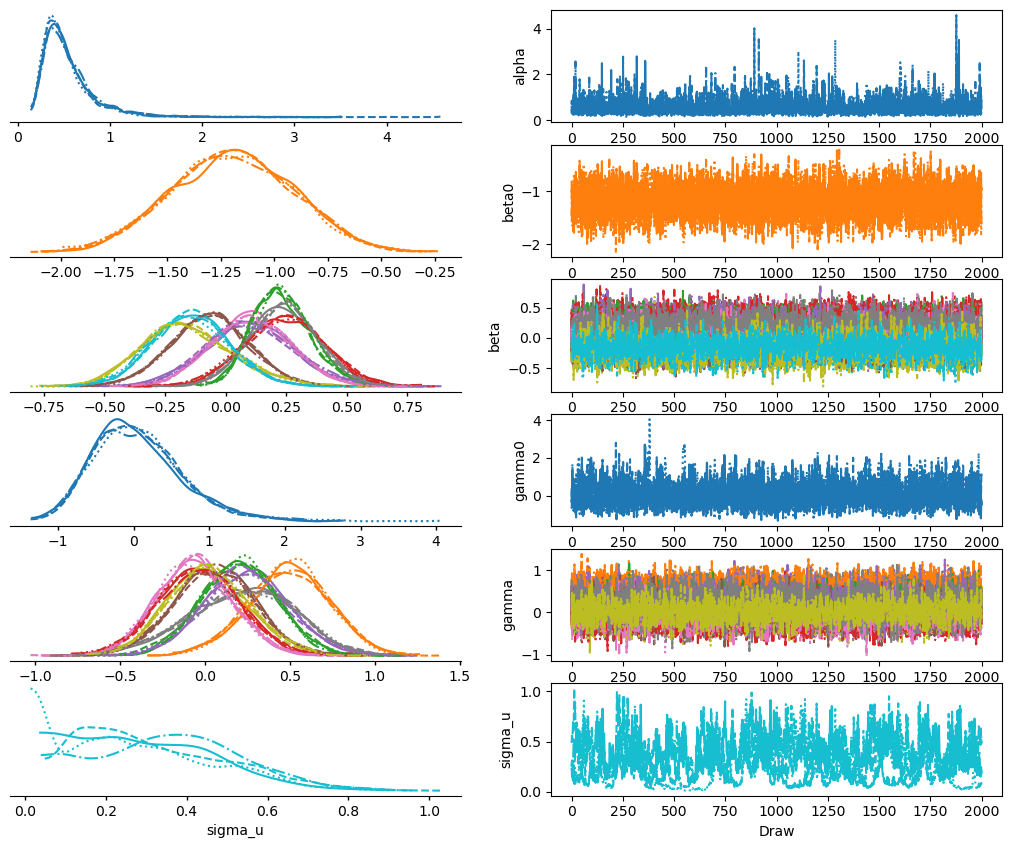

In [11]:
az.plot_trace_dist(idata,var_names=["alpha","beta0","beta","gamma0","gamma","sigma_u"])

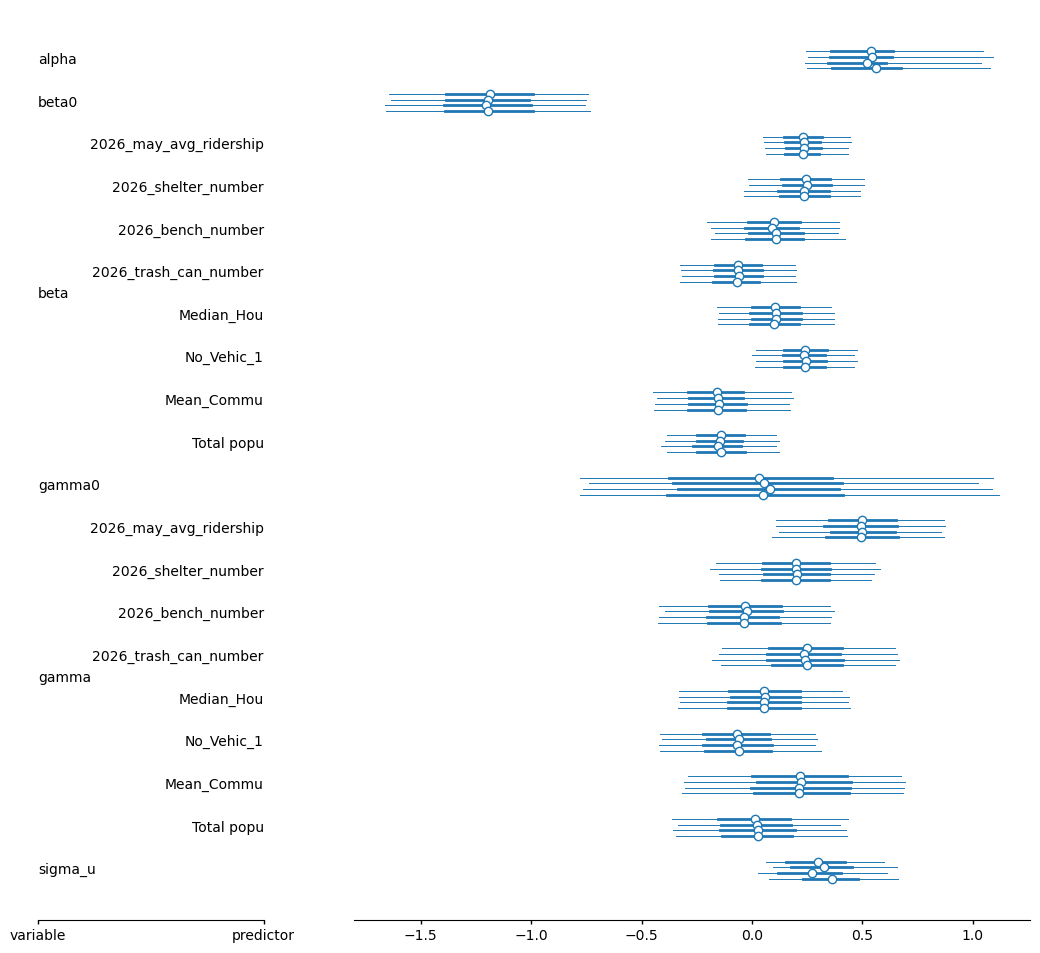

In [12]:
az.plot_forest(idata,var_names=["alpha","beta0","beta","gamma0","gamma","sigma_u"])

# Targeted Output & Visualization

In [13]:
posterior_mu = idata.posterior["mu"]
posterior_psi = idata.posterior["psi"]

# this is E(Y|X,y) = E(E(Y|X,theta)|X,y) / tower property
posterior_expectation = posterior_mu * posterior_psi

model_df["predicted_need_mean"] = posterior_expectation.mean(dim=("chain","draw")).values
model_df["predicted_need_low"] = posterior_expectation.quantile(0.025,dim=("chain","draw")).values
model_df["predicted_need_high"] = posterior_expectation.quantile(0.975,dim=("chain","draw")).values

model_df["prob_count_process"] = posterior_psi.mean(dim=("chain", "draw")).values

model_df["need_rank"] = model_df["predicted_need_mean"].rank(
    ascending=False,
    method="min"
)

model_df["need_tier"] = pd.qcut(
    model_df["predicted_need_mean"],
    q=[0, 0.5, 0.75, 0.9, 1.0],
    labels=["Tier 4", "Tier 3", "Tier 2", "Tier 1"]
)

# 10. View results
result_cols = [
   'Stop Code', 'stop_name', 'lattitude', 'longitude',
    "GEOID_right",
    "2026_complaint_counts",
    "2026_may_avg_ridership",
    "2026_shelter_number",
    "2026_bench_number",
    "2026_trash_can_number",
    "predicted_need_mean",
    "predicted_need_low",
    "predicted_need_high",
    "prob_count_process",
    "need_rank",
    "need_tier"
]

results = model_df[result_cols].sort_values(
    "predicted_need_mean",
    ascending=False
)

results = results.set_index("Stop Code")
